# CNN Implementation for Binary Image Classification on Pet Images - Cats & Dogs

In this project, I implemented a Convolutional Neural Network (CNN) architecture for binary image classification on the Cats vs Dogs dataset. The project began with inspecting and removing corrupted images from the dataset, followed by data preprocessing and data loading using PyTorch utilities.

After preparing the data for model training, I designed and implemented a CNN architecture consisting of convolutional, pooling, dropout, and fully connected layers. The model was then trained and validated on the dataset to classify images as either cats or dogs.

The final model achieved approximately **81.98%** validation accuracy, demonstrating the effectiveness of CNNs for image classification tasks while also providing insights into concepts such as preprocessing, overfitting, loss functions, and model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch
import torch.nn as nn
import seaborn as sns

Firstly, we need to convert images -> tensors to feed to our CNN as it expects images to be of same size, numerical tensors and normalized so, we need to perform some image preprocessing


### Inpect Dataset

In [2]:
import os
cat_path = r'C:\Users\LENOVO\Downloads\archive\PetImages\Cat';
dog_path = r'C:\Users\LENOVO\Downloads\archive\PetImages\Dog';

print("Cats: ", len(os.listdir(cat_path)))
print("Dogs: ", len(os.listdir(dog_path)))


Cats:  12499
Dogs:  12498


### Remove Corrupted Images

In [3]:
from PIL import Image
import os
import warnings

dataset_path = r"C:\Users\LENOVO\Downloads\archive\PetImages"

for folder in ["Cat", "Dog"]:

    folder_path = os.path.join(dataset_path, folder)

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error")

                with Image.open(file_path) as img:
                    img.load()

        except Exception as e:
            print("Removing:", file_path)
            os.remove(file_path)

In [4]:
print(len(os.listdir(cat_path)))
print(len(os.listdir(dog_path)))

12499
12498


### Transform to 128*128 image size, Convert to Tensors and create dataset using ImageFolder

In [21]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(
    root=r'C:\Users\LENOVO\Downloads\archive\PetImages',
    transform=transform
)

print(dataset.class_to_idx)

{'Cat': 0, 'Dog': 1}


### Creating Train and Validation Splits

In [22]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(
    dataset, 
    [train_size, val_size]
)

In [23]:
print(len(train_dataset))
print(len(val_dataset))

19997
5000


### Creating Data Loader

In [24]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)

In [25]:
train_loader

In [26]:
images, labels = next(iter(train_loader)) # obtaining 1 batch from train loader, images-> image tensor, labels -> corresponding label
print(images.shape)
print(labels)

classes = dataset.classes # label meaning
print(classes)

torch.Size([32, 3, 64, 64])
tensor([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        1, 0, 1, 0, 0, 1, 1, 1])
['Cat', 'Dog']


#### Image Data is now in correct format to continue with modeling and training/testing

### Visualizing Image Data

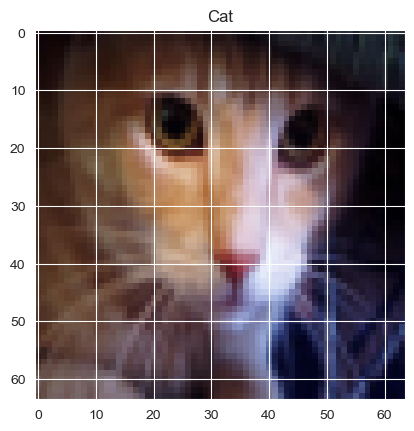

In [27]:
plt.imshow(images[0].permute(1,2,0))
plt.title(dataset.classes[labels[0]])
plt.show()

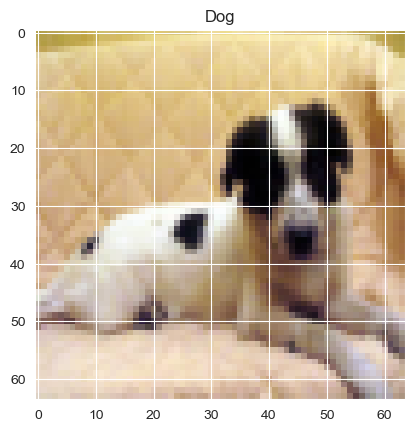

In [50]:
plt.imshow(images[4].permute(1,2,0))
plt.title(dataset.classes[labels[4]])
plt.show()

### CNN Model Architecture

In [33]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size = 3, padding = 1), # inp, outp channel (32 * 64 * 64) with 32 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # kernel size, stride (32 * 32 *32)

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1), # increase feature map -> 64 (64 * 32 * 32)
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # (64 * 16 * 16)

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1), # (128 * 16 * 16)
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # (128, 8, 8)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128*8*8, 64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 1) # output -> [32,1]
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening
        x = self.fc_layers(x)

        return x

### Defining CNN Model

In [34]:
model = CNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

### Training and Validation Loop

In [36]:
epochs = 6
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):
    running_train_loss = 0.0
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        labels = labels.float().unsqueeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()  # 1 batch loss
    epoch_train_loss = running_train_loss/len(train_loader) # 1 epoch loss
    train_losses.append(epoch_train_loss) 

    # Validation loop
    model.eval()
    running_val_losses = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            labels = labels.float().unsqueeze(1)
            loss = criterion(outputs, labels)
            running_val_losses += loss.item()
        epoch_val_losses = running_val_losses/len(test_loader)
        val_losses.append(epoch_val_losses)

        print(f"Epoch -> {epoch+1}/{epochs}, Training Loss -> {epoch_train_loss}, Validation Loss -> {epoch_val_losses}")

        # Saving best model
    
        if epoch_val_losses < best_val_loss:
            best_val_loss = epoch_val_losses
            torch.save(model.state_dict(), "best_cnn_model.pt")

Epoch -> 1/6, Training Loss -> 0.5611913543701171, Validation Loss -> 0.5229595979307867
Epoch -> 2/6, Training Loss -> 0.5141221386909485, Validation Loss -> 0.48313376231558003
Epoch -> 3/6, Training Loss -> 0.47781338224411013, Validation Loss -> 0.488909636902961
Epoch -> 4/6, Training Loss -> 0.4506711116075516, Validation Loss -> 0.4696098583139432
Epoch -> 5/6, Training Loss -> 0.4199769516706467, Validation Loss -> 0.4206222054684997
Epoch -> 6/6, Training Loss -> 0.39776840019226073, Validation Loss -> 0.40771092645301943


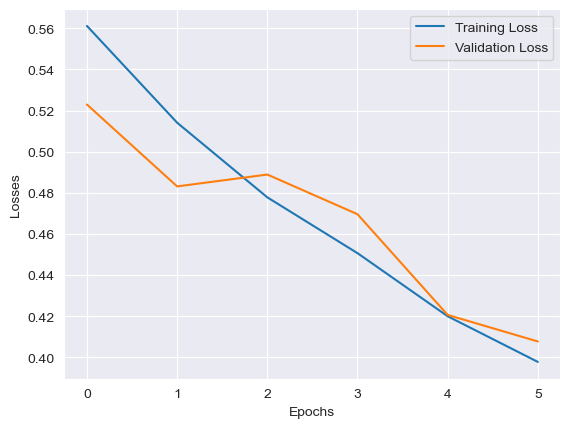

In [37]:

losses_df = pd.DataFrame({
    "Training_Loss" : train_losses,
    "Validation_Loss": val_losses
})
sns.set_style("darkgrid")
plt.plot(losses_df["Training_Loss"], label = "Training Loss" )
plt.plot(losses_df["Validation_Loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

In [38]:
model.load_state_dict(torch.load("best_cnn_model.pt"))

<All keys matched successfully>

In [39]:
correct_labels = 0
total_labels = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        probabilities = torch.sigmoid(outputs)
        predicted = (probabilities > 0.5).float()
        predicted = predicted.squeeze(1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)
    print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 81.98
